# Train pre-trained ADAGE models on Staph epi data

### Georgia Doing 2022

This notebook walks through traineding pre-trained models on S. epi data
The main objectives are to validate the training workflow using
1. Loss and validation loss curves
2. Node weight distributions
3. Node KEGG and GO enrichments

In [15]:
import run_model_preT
import run_model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#from imp import reload
from importlib import reload
import Adage
from scipy.stats import hypergeom
import csv
import time

In [16]:
import tensorflow as tf

print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  0
False


In [6]:
# for dev purposes, while updating run_model.py need to reload
# for dev purposes, while updating run_model.py need to reload
reload(run_model_preT)
reload(run_model)
reload(Adage)

<module 'Adage' from '/hpc/group/ohlab/doingg/seqADAGE/Py/Adage.py'>

## Base features (from ADAGE)

For the sake of this efficiency, starting with the following parameters:

* hidden features: 300
* epochs: 500
* curruption: 0.01
* batchs zie: 10
* validatoin split: 0.1
* activation: sigmoid
* objective: binary cross-entropy



17595 350


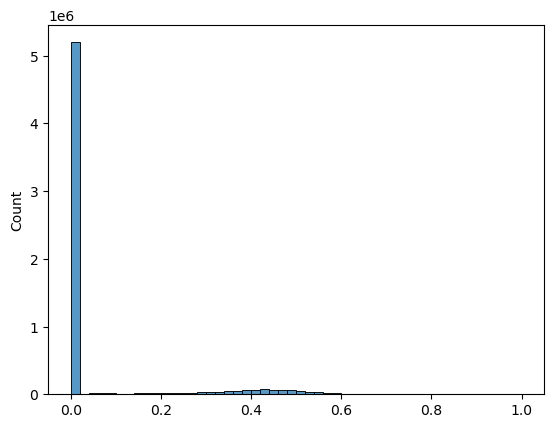

In [17]:
#adage_comp = pandas.read_csv('data_files/ADAGE_compendium.csv')
all_comp = np.loadtxt(open('../data_files/sepi_pan_genome_log_counts_norm_01_nonames.csv', "rb"),delimiter=',',skiprows = 1)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)
print(gene_num, samp_num)
fig = sns.histplot(all_comp.flatten(), bins = 50)

17595 3327


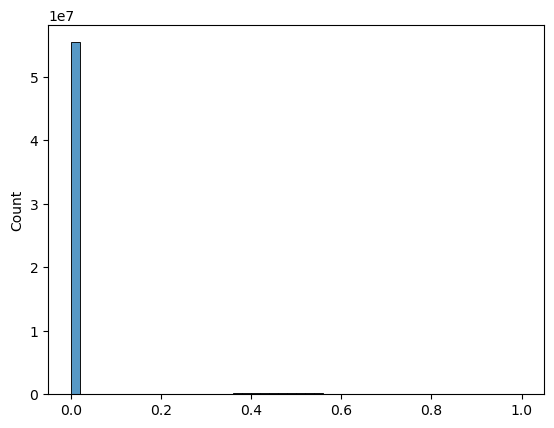

In [18]:
#adage_comp = pandas.read_csv('data_files/ADAGE_compendium.csv')
all_comp = np.loadtxt(open('../data_files/saur_pan_genome_BLAST_trimmed_log_counts_norm_01_nonames.csv', "rb"),delimiter=',',skiprows = 1)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)
print(gene_num, samp_num)
fig = sns.histplot(all_comp.flatten(), bins = 50)

In [19]:
inits = ['glorot_uniform', 'glorot_normal']
L1_norm = [0, 1e-5]
L2_norm = [0, 1e-5]
act_fun = ['sigmoid', 'tanh','relu']
tied = [True, False]
stime = time.time()
seq_temp, seq_temp2 = run_model_preT.run_model('../data_files/se_se16_epi_comp_log_counts_norm_01.csv',
                                               '../data_files/se_se16_epi_comp_log_counts_norm_01.csv',
                                               960, enc_dim = 50, kl1=0, act = 'tanh', tied = True, epochs=10, init='glorot_normal')
rtime = time.time() - stime

tied
made ae
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1910 - val_loss: 0.1865
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1850 - val_loss: 0.1766
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1737 - val_loss: 0.1626
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1590 - val_loss: 0.1465
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1421 - val_loss: 0.1301
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1259 - val_loss: 0.1146
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1107 - val_loss: 0.1004
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0967 - val_loss: 0.0878
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0846 - val_loss: 0.0769
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0737 - val_loss: 0.0675
fitted
preT ae ae
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0663 - val_loss: 0.0629
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5

In [6]:
print(rtime)

33.87628531455994


In [ ]:
inits = ['glorot_uniform', 'glorot_normal']
L1_norm = [0, 1e-5]
L2_norm = [0, 1e-5]
act_fun = ['sigmoid', 'tanh','relu']
tied = [True]

model_dict2 = {
   # "tf_adage": tf_adage
}

model_dict_pre = {
   # "tf_adage": tf_adage
}

model_dict_seq2 = {
   # "tf_adage": tf_adage
}

stime = time.time()
ltime = 0
c = 0
for seed in range(1):
    for i in inits:
    #print(i)
        for l in L1_norm:
        #print(l)
            for a in act_fun:
            #print(a)
                for t in tied:
                    name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t)+ str(seed+572)
                    print(name)
                    ttime = time.time()
                    mseqpre , mseq = run_model_preT.run_model('../data_files/saur_pan_genome_BLAST_trimmed_log_counts_norm_01.csv',
                                                              '../data_files/sepi_pan_genome_log_counts_norm_01.csv',
                                                              seed=seed+571,
                                                              enc_dim = 50,
                                                              kl1=l, 
                                                              act = a, 
                                                              tied = t, 
                                                              epochs=30, 
                                                              init=i, 
                                                              lr = 0.1)
                    #marr = run_model.run_model('../data_files/train_set_normalized.csv',seed=seed+560,kl1=l, act = a, tied = t, epochs=300, init=i, lr = 0.1)

                    #model_dict2[name] = marr
                    model_dict_pre[name] = mseqpre
                    model_dict_seq2[name] = mseq
                    ltime = ((time.time() - ttime) + ltime) 
                    c+=1

rtime = time.time() - stime

ad_glorot_uniform_0_sigmoid_tiedTrue572
tied
made ae
Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.2020 - val_loss: 0.1836
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1749 - val_loss: 0.1506
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1435 - val_loss: 0.1243
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1188 - val_loss: 0.1039
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0996 - val_loss: 0.0880
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0847 - val_loss: 0.0756
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0729 - val_loss: 0.0657
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0636 - val_loss: 0.0579
Epoch 9/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0561 - val_loss: 0.0515
Epoch 10/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0501 - val_loss: 0.0462
Epoch 11/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0450 - val_l

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0125 - val_loss: 0.0127
Epoch 106/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0125 - val_loss: 0.0127
Epoch 107/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0125 - val_loss: 0.0127
Epoch 108/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0124 - val_loss: 0.0127
Epoch 109/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0125 - val_loss: 0.0127
Epoch 110/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0125 - val_loss: 0.0127
Epoch 111/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0125 - val_loss: 0.0127
Epoch 112/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0125 - val_loss: 0.0127
Epoch 113/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0125 - val_loss: 0.0127
Epoch 114/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0125 - val_loss: 0.0127
Epoch 115/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0125 - val_loss: 0.0127
Epoch 116/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13

In [ ]:
print(rtime)
print(c)
print(ltime / c)
print(rtime/60)

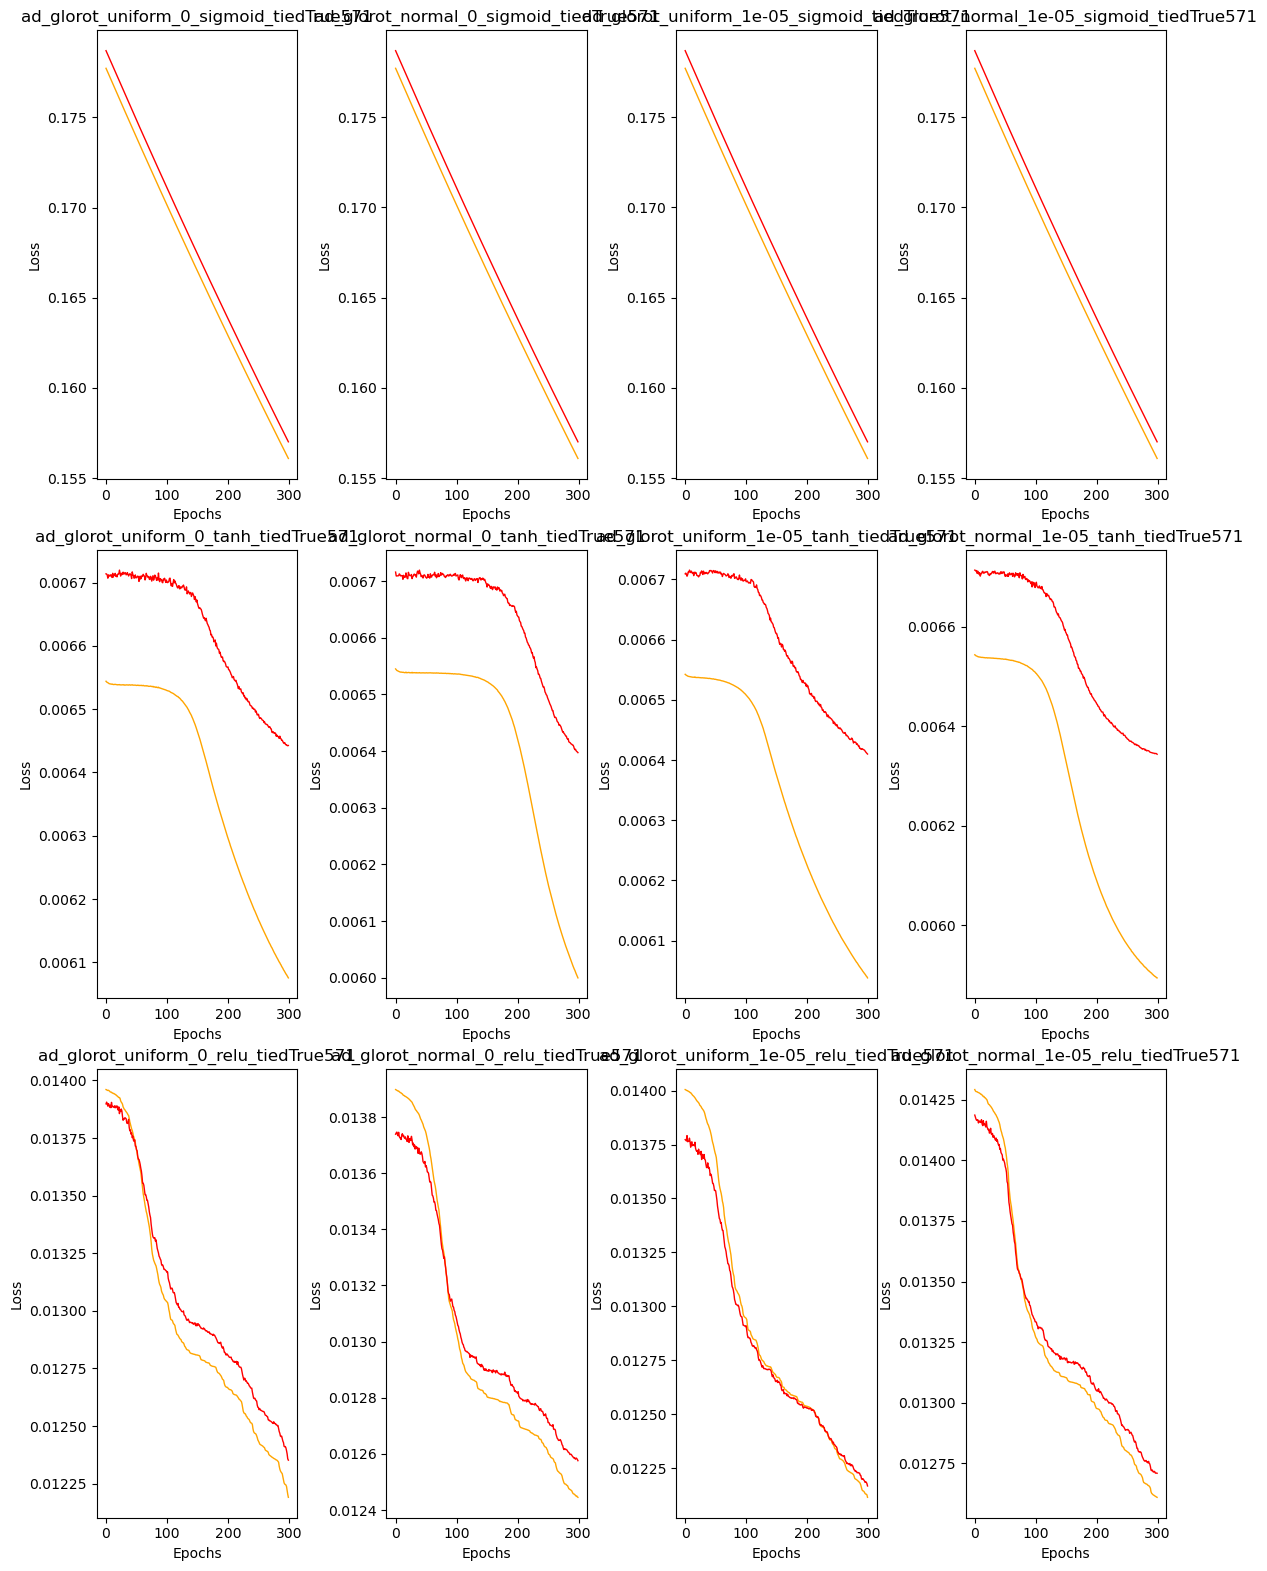

In [8]:
model_dict = model_dict_seq2

yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(xd*4 ,yd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict[name]
                ax[xi,yi].plot(list(range(0,300)), model_temp.loss, linewidth=1, markersize=2, color = 'orange')
                ax[xi,yi].plot(list(range(0,300)), model_temp.val_loss, linewidth=1, markersize=2, color = 'red')
                ax[xi,yi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
                xi = xi+1
        yi=yi+1


    

In [1]:
model_dict = model_dict_pre

yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(xd*4 ,yd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict[name]
                ax[xi,yi].plot(list(range(0,10)), model_temp.loss, linewidth=1, markersize=2, color = 'orange')
                ax[xi,yi].plot(list(range(0,10)), model_temp.val_loss, linewidth=1, markersize=2, color = 'red')
                ax[xi,yi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
                xi = xi+1
        yi=yi+1


    

NameError: name 'model_dict_pre' is not defined

KeyboardInterrupt: 

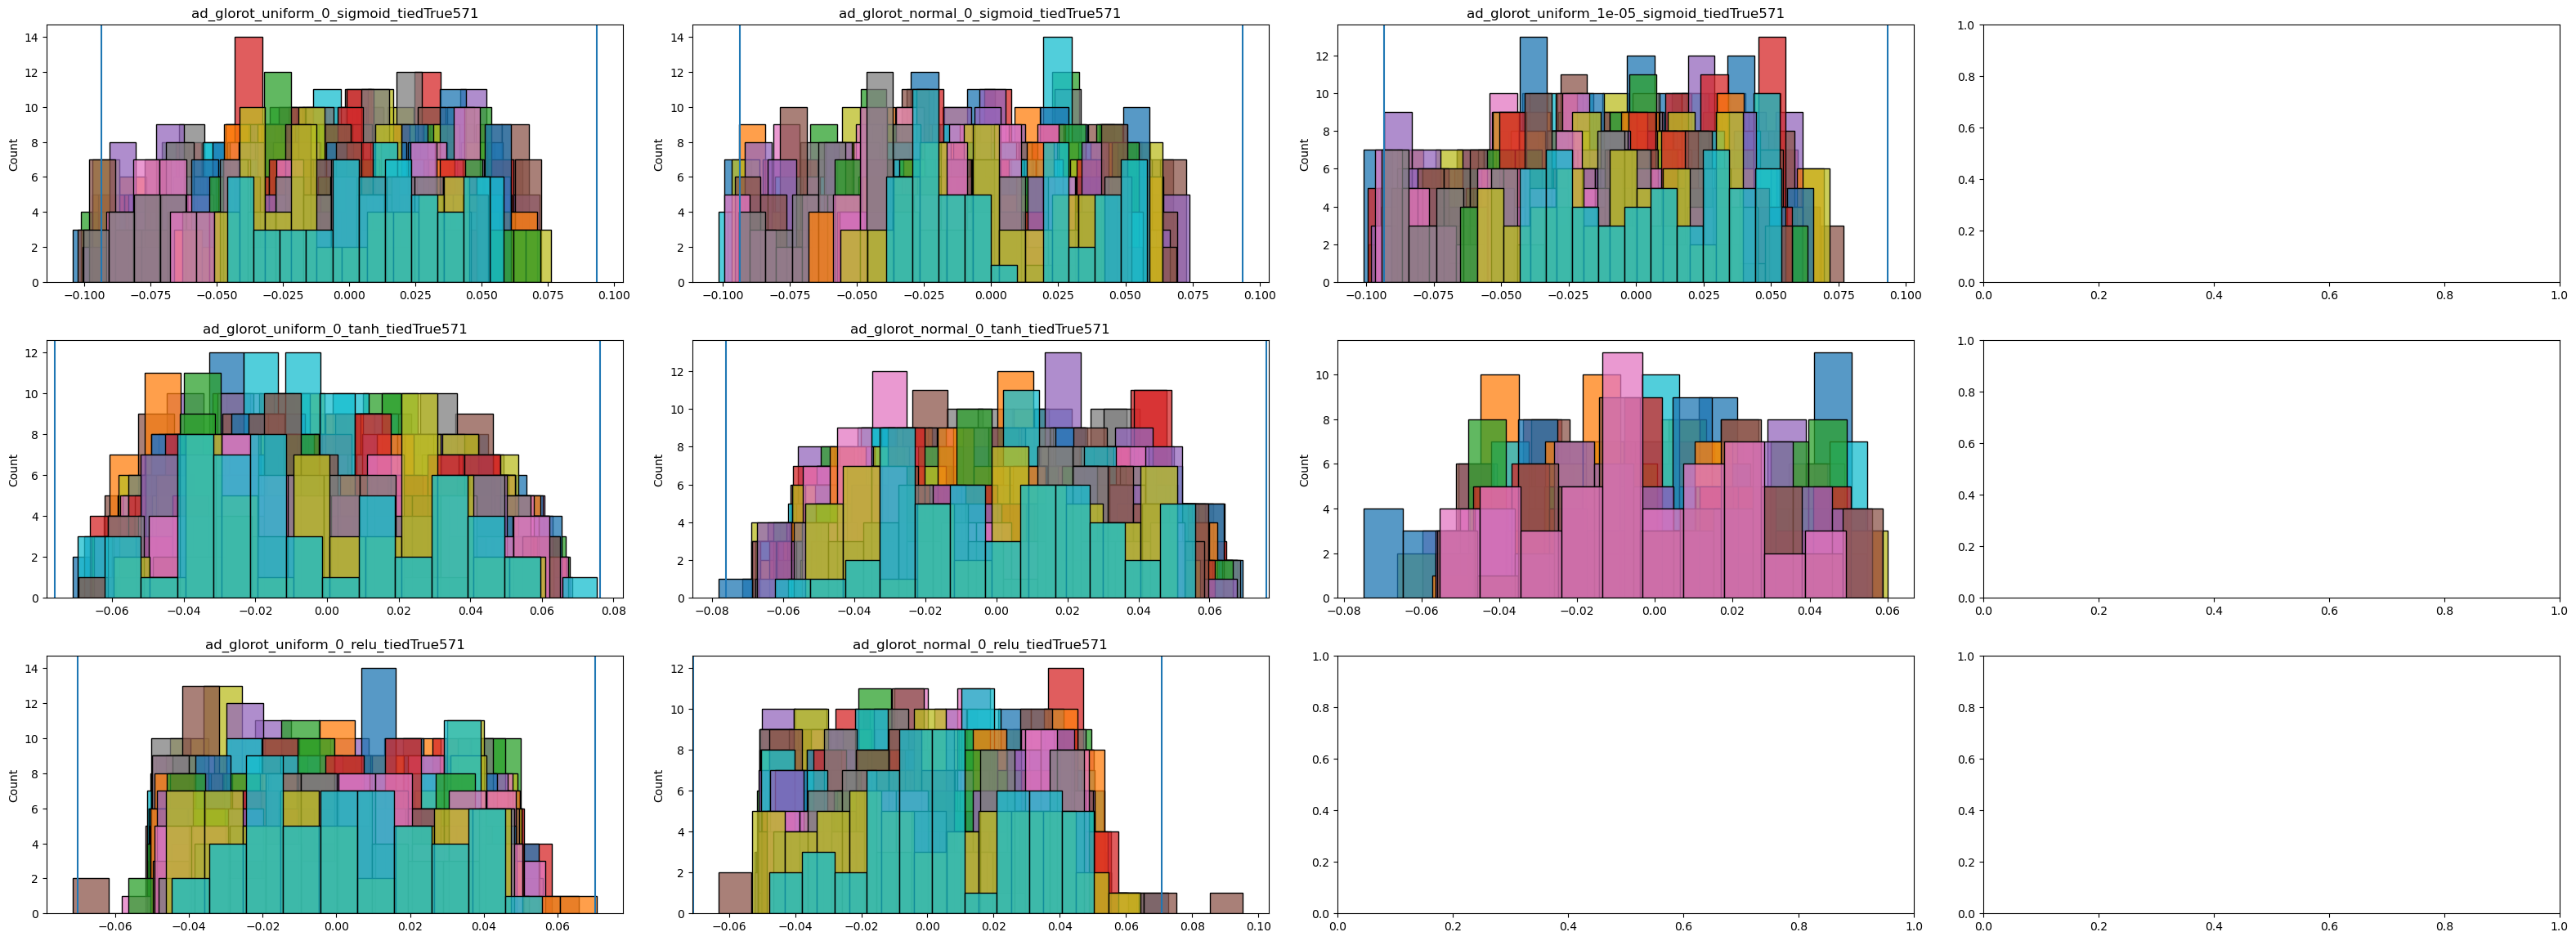

In [4]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_seq2[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1


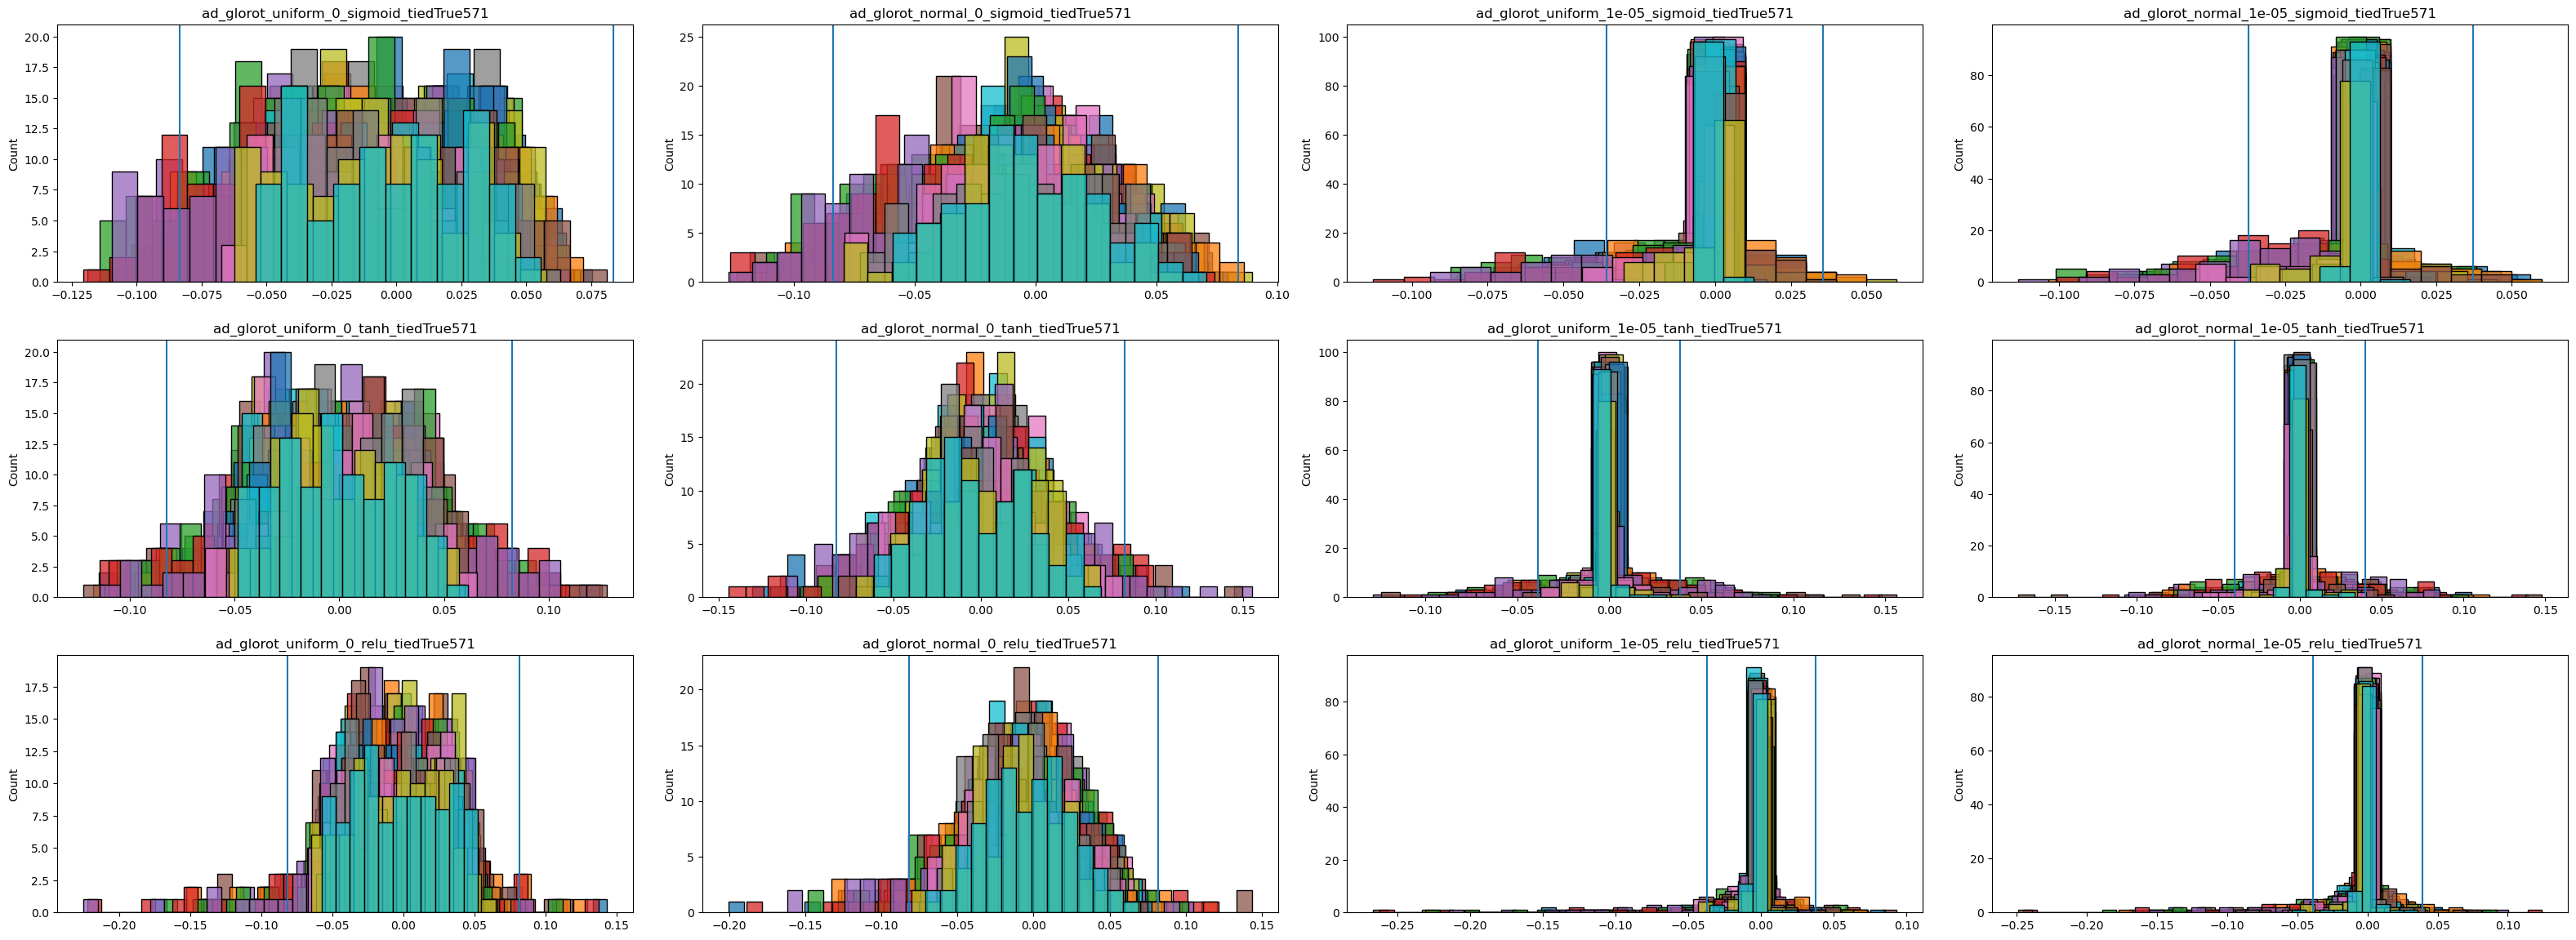

In [16]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_seq2CTRL[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1

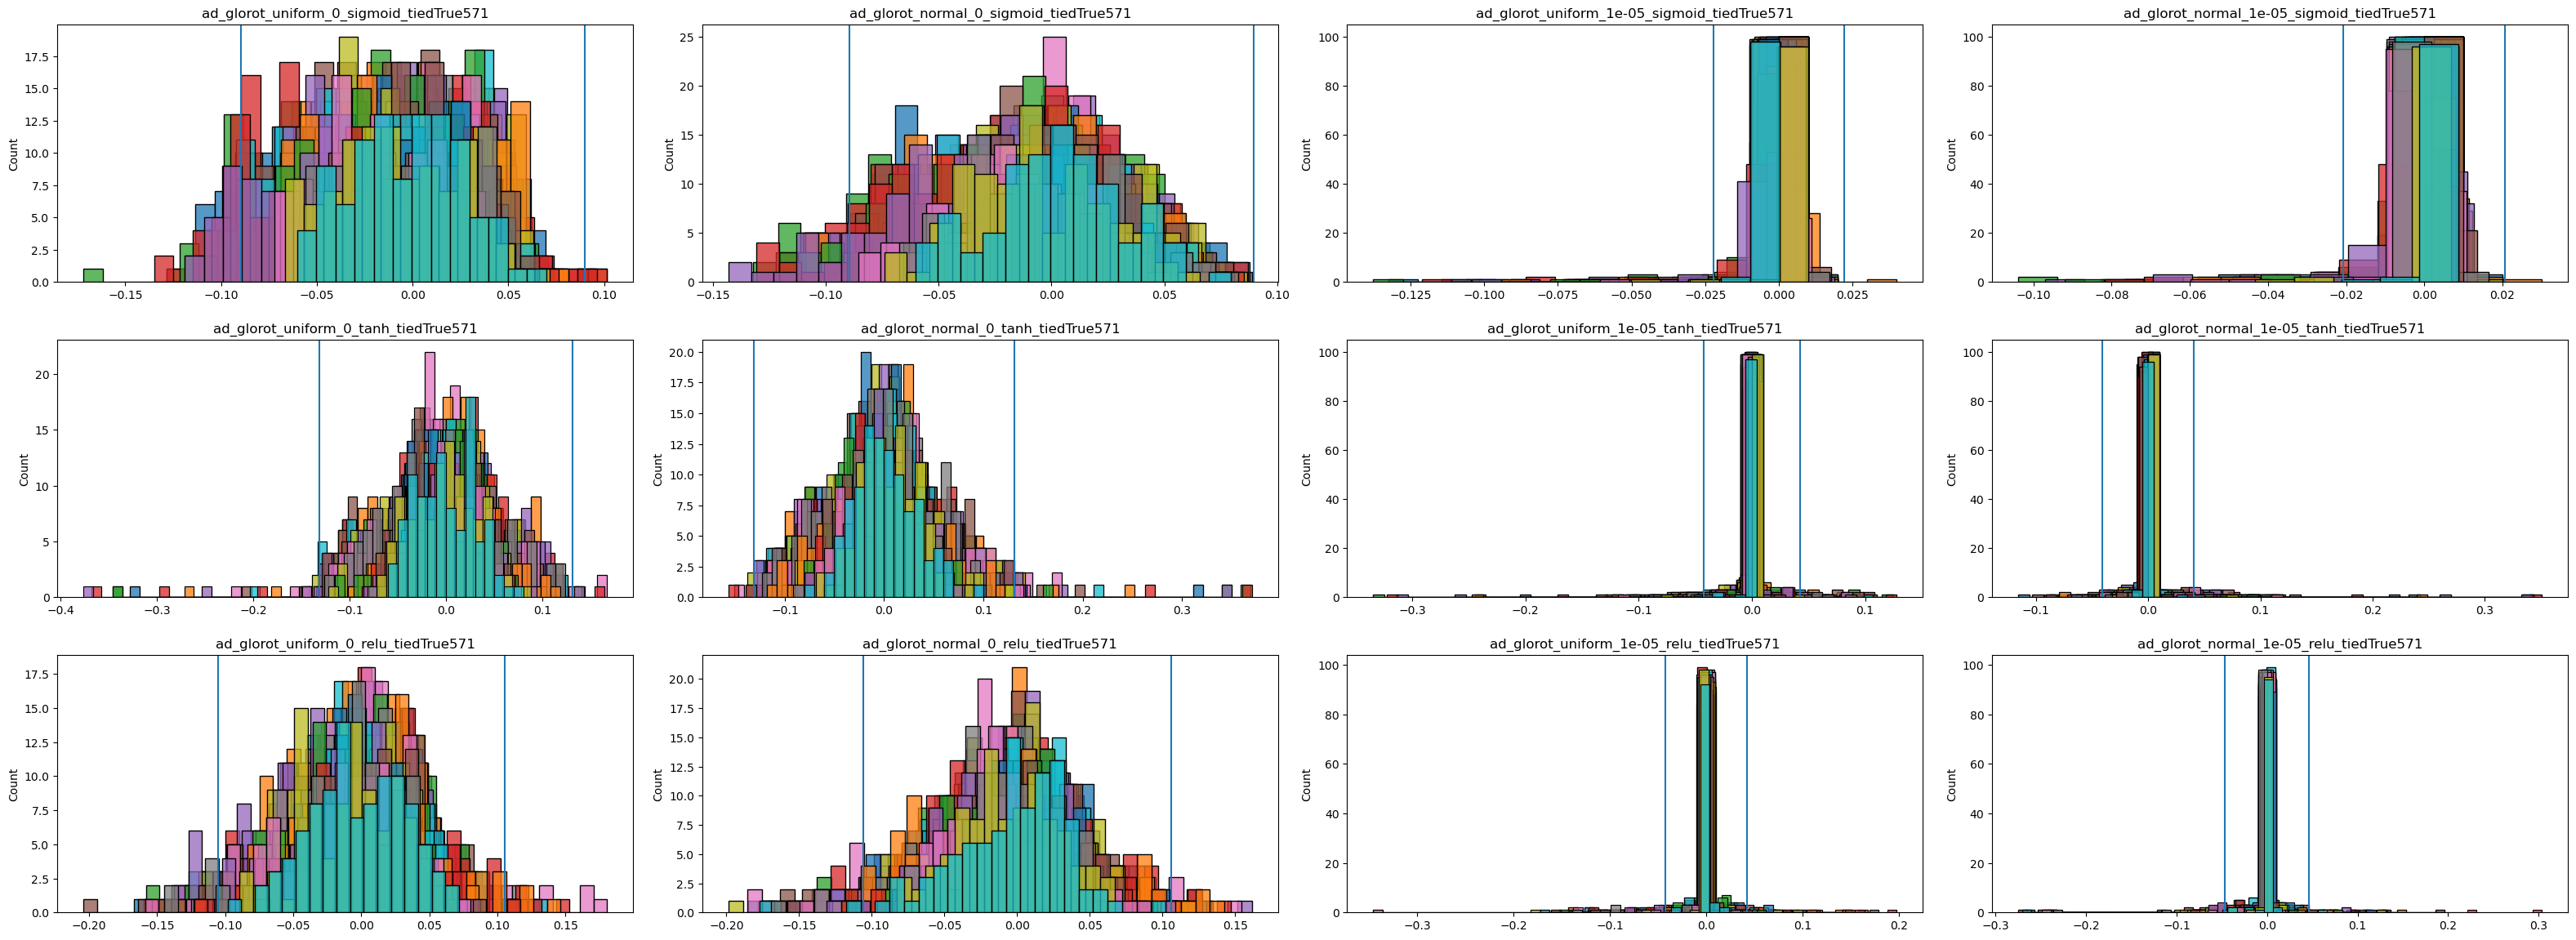

In [17]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_seq2[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1


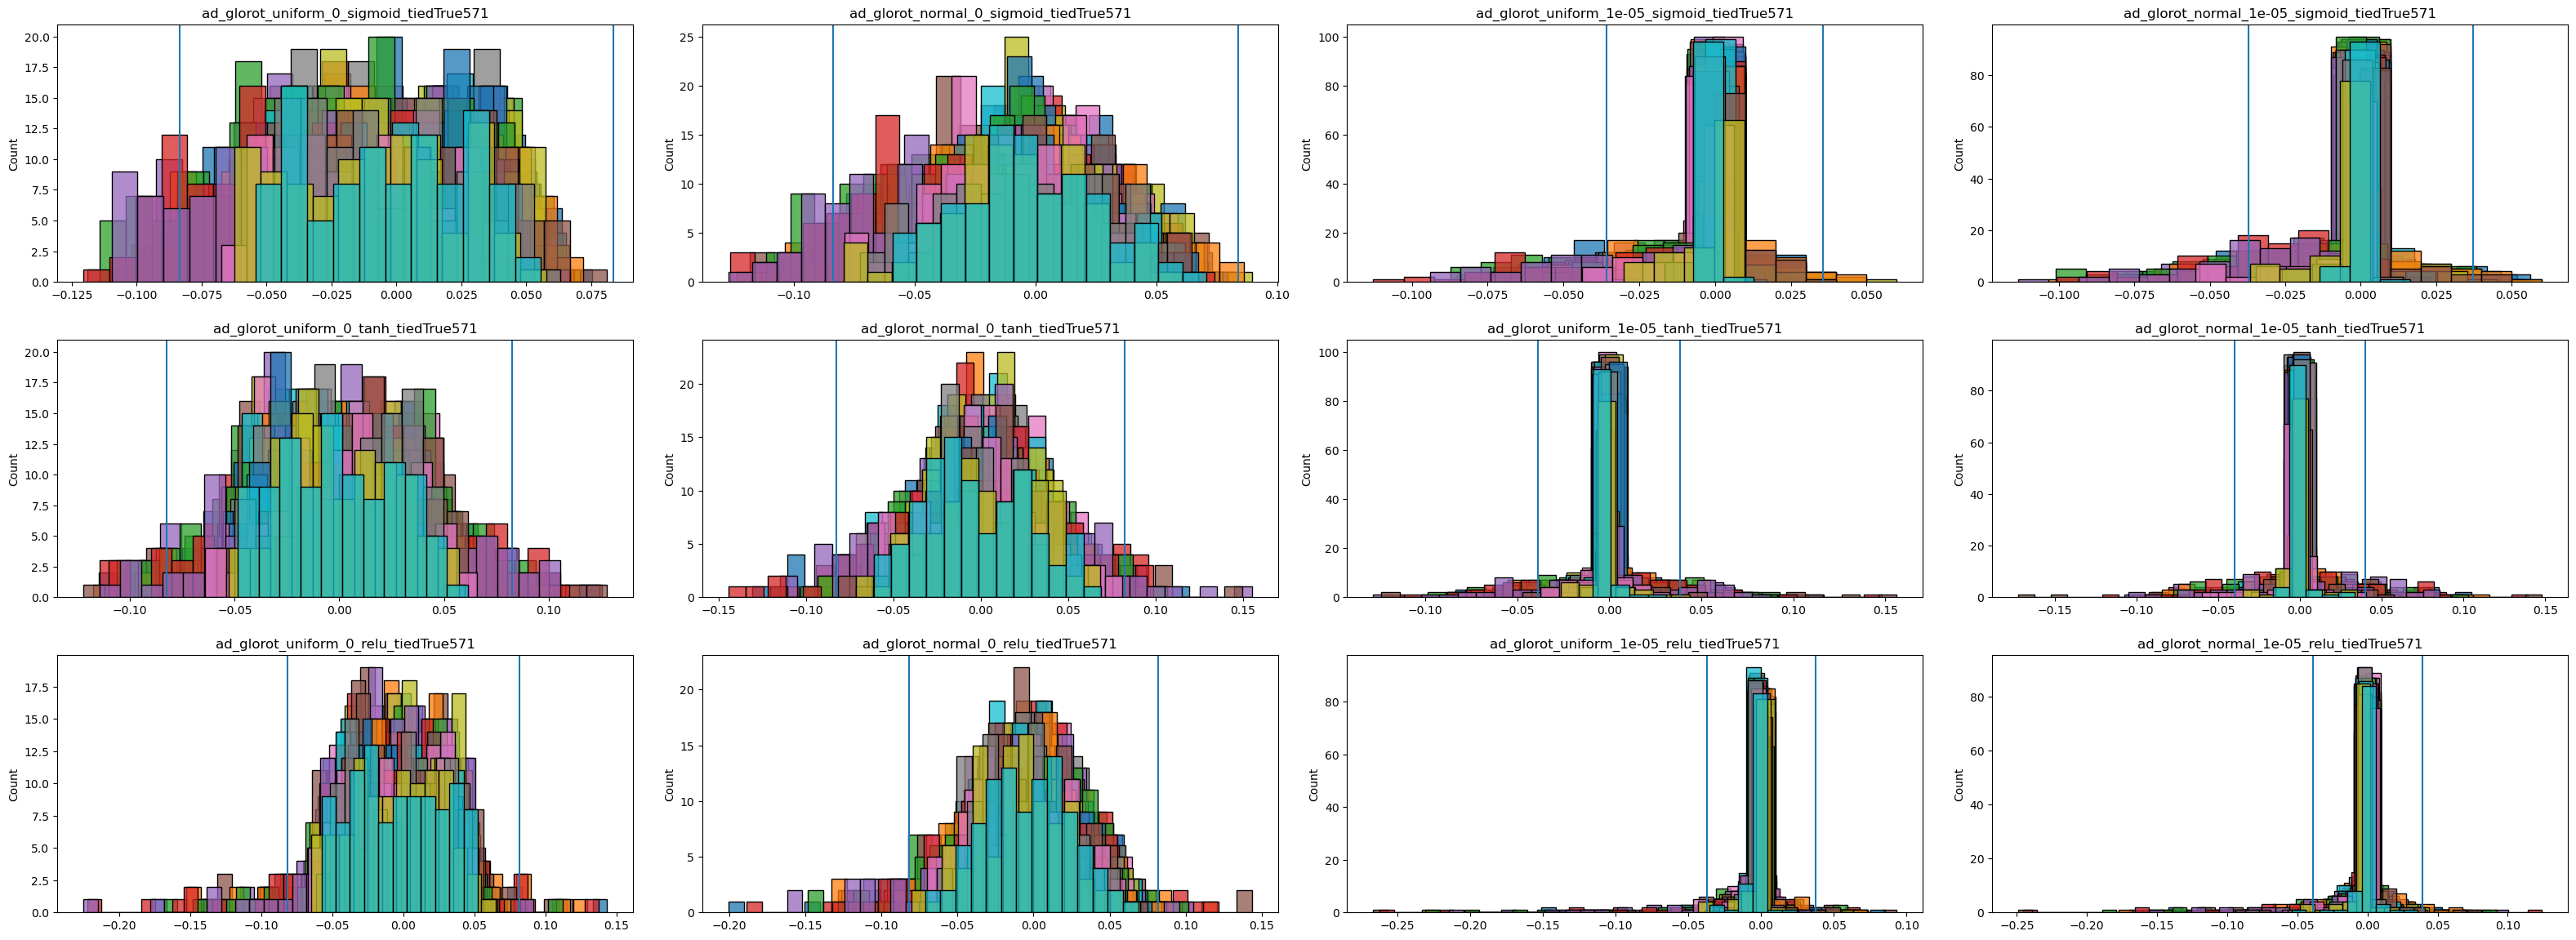

In [18]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_seq2CTRL[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1


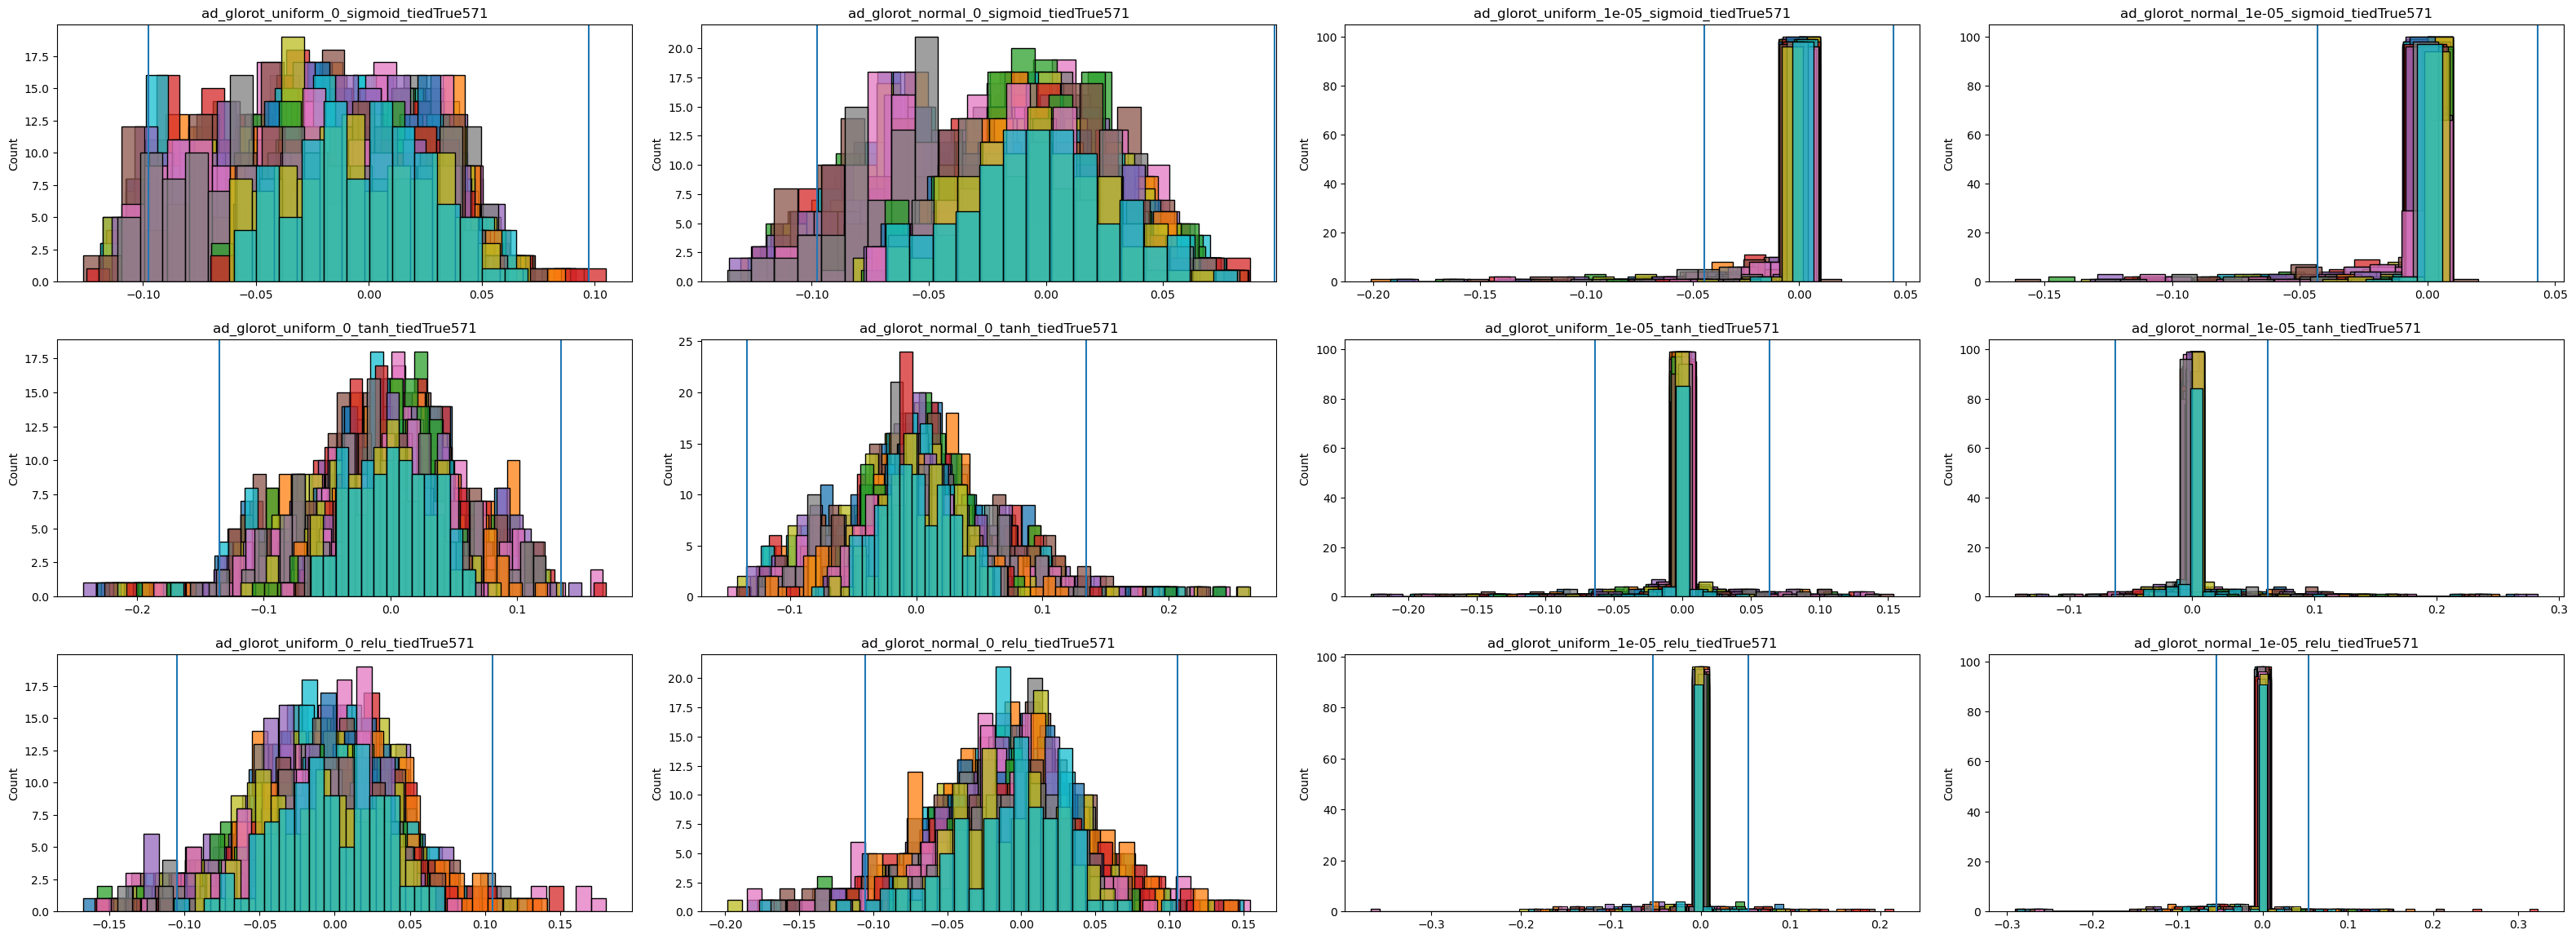

In [19]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_pre[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1

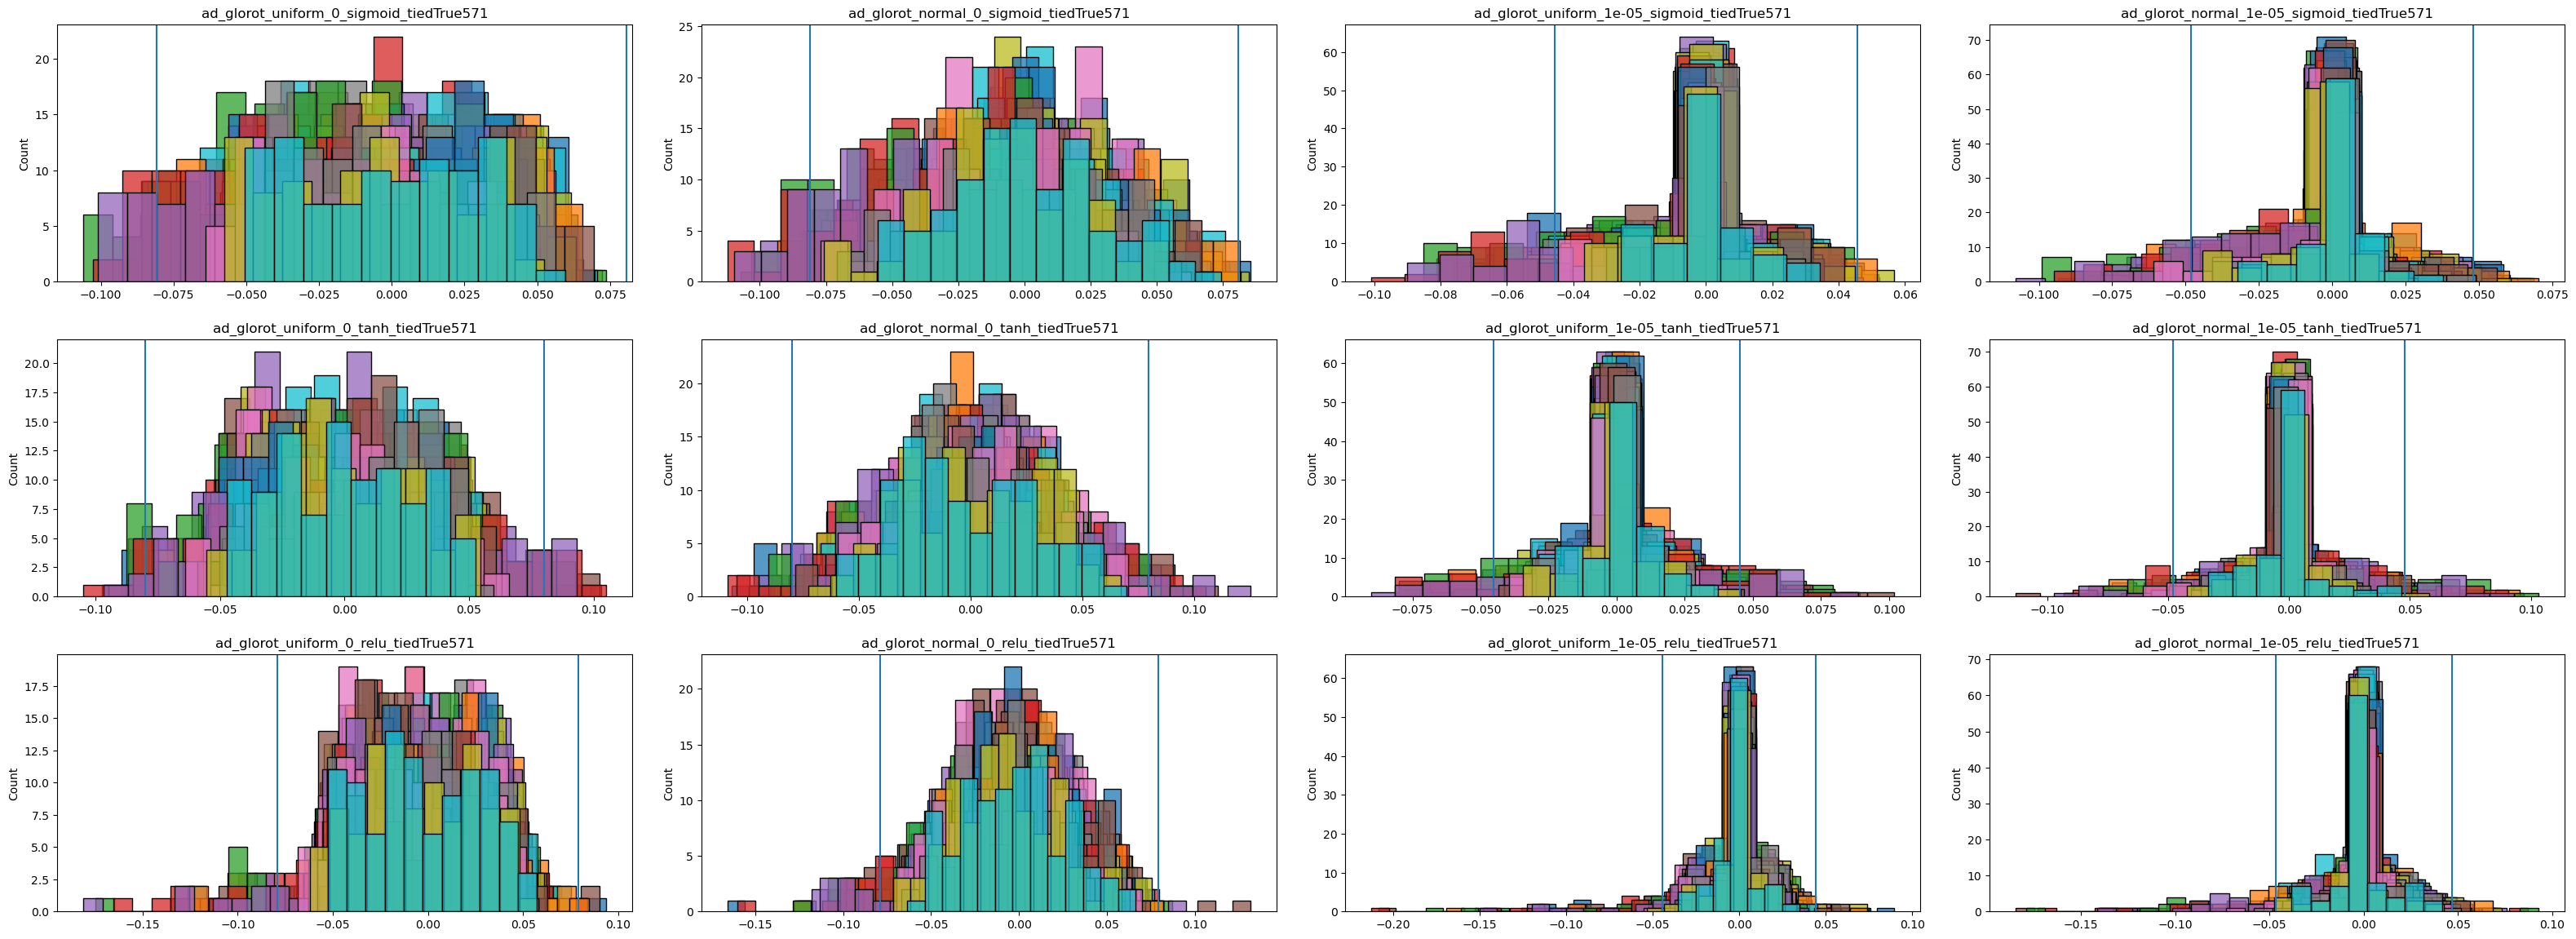

In [20]:
yd = len(inits) * len(L1_norm)
xd = len(act_fun) * len(tied)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

xi = 0
yi = 0
for l in L1_norm:
    for i in inits:
        xi = 0
        for a in act_fun:
            for t in tied:
                name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                #print(name)
                model_temp = model_dict_preCTRL[name]
                for node in range(0,100):
                    sns.histplot(model_temp.weights[node], #[model_temp.weights[node] > 0],
                        ax=ax[xi,yi],
                        #hist=True,
                        binwidth = 0.01, 
                        #stat="density",
                        kde=False
                        #rug=False
                                )
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
                ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
                ax[xi,yi].set(title = name)
                xi = xi+1
        yi=yi+1

In [37]:
model_temp = model_dict_seq2
#del model_temp['tf_adage']
for m in model_temp:
    print(m)
    model_dict_seq2[m].set_hwg_cutoff(2.5)
    #model_dict_seq2[m].set_op('../node_interpretation/operons_format.txt')
    #print('op done')
    model_dict_seq2[m].set_kegg('../node_interpretation/se16_KEGG_format.txt') 
    #print('kegg done')
    #model_dict_seq2[m].set_go('../node_interpretation/manual_GO_BP_terms.txt') 
    #print('go done')
    #model_dict_seq2[m].set_reg('../node_interpretation/regulons_format.txt')
    #print('reg done')
print('dict done') 

model_temp = model_dict_seq2CTRL
#del model_temp['tf_adage']
for m in model_temp:
    print(m)
    model_dict_seq2CTRL[m].set_hwg_cutoff(2.5)
    #model_dict_seq2[m].set_op('../node_interpretation/operons_format.txt')
    #print('op done')
    model_dict_seq2CTRL[m].set_kegg('../node_interpretation/se16_KEGG_format.txt') 
    #print('kegg done')
    #model_dict_seq2[m].set_go('../node_interpretation/manual_GO_BP_terms.txt') 
    #print('go done')
    #model_dict_seq2[m].set_reg('../node_interpretation/regulons_format.txt')
    #print('reg done')
print('dict done') 


model_temp = model_dict_pre
#del model_temp['tf_adage']
for m in model_temp:
    print(m)
    model_dict_pre[m].set_hwg_cutoff(2.5)
    #model_dict_seq2[m].set_op('../node_interpretation/operons_format.txt')
    #print('op done')
    model_dict_pre[m].set_kegg('../node_interpretation/se16_KEGG_format.txt') 
    #print('kegg done')
    #model_dict_seq2[m].set_go('../node_interpretation/manual_GO_BP_terms.txt') 
    #print('go done')
    #model_dict_seq2[m].set_reg('../node_interpretation/regulons_format.txt')
    #print('reg done')
print('dict done')


model_temp = model_dict_preCTRL
#del model_temp['tf_adage']
for m in model_temp:
    print(m)
    model_dict_preCTRL[m].set_hwg_cutoff(2.5)
    #model_dict_seq2[m].set_op('../node_interpretation/operons_format.txt')
    #print('op done')
    model_dict_preCTRL[m].set_kegg('../node_interpretation/se16_KEGG_format.txt') 
    #print('kegg done')
    #model_dict_seq2[m].set_go('../node_interpretation/manual_GO_BP_terms.txt') 
    #print('go done')
    #model_dict_seq2[m].set_reg('../node_interpretation/regulons_format.txt')
    #print('reg done')
print('dict done')

tf_adage
ad_glorot_uniform_0_sigmoid_tiedTrue571
ad_glorot_uniform_0_tanh_tiedTrue571
ad_glorot_uniform_0_relu_tiedTrue571
ad_glorot_uniform_1e-05_sigmoid_tiedTrue571
ad_glorot_uniform_1e-05_tanh_tiedTrue571
ad_glorot_uniform_1e-05_relu_tiedTrue571
ad_glorot_normal_0_sigmoid_tiedTrue571
ad_glorot_normal_0_tanh_tiedTrue571
ad_glorot_normal_0_relu_tiedTrue571
ad_glorot_normal_1e-05_sigmoid_tiedTrue571
ad_glorot_normal_1e-05_tanh_tiedTrue571
ad_glorot_normal_1e-05_relu_tiedTrue571
dict done
tf_adage
ad_glorot_uniform_0_sigmoid_tiedTrue571
ad_glorot_uniform_0_tanh_tiedTrue571
ad_glorot_uniform_0_relu_tiedTrue571
ad_glorot_uniform_1e-05_sigmoid_tiedTrue571
ad_glorot_uniform_1e-05_tanh_tiedTrue571
ad_glorot_uniform_1e-05_relu_tiedTrue571
ad_glorot_normal_0_sigmoid_tiedTrue571
ad_glorot_normal_0_tanh_tiedTrue571
ad_glorot_normal_0_relu_tiedTrue571
ad_glorot_normal_1e-05_sigmoid_tiedTrue571
ad_glorot_normal_1e-05_tanh_tiedTrue571
ad_glorot_normal_1e-05_relu_tiedTrue571
dict done
tf_adage
ad_gl

ad_glorot_uniform_0_sigmoid_tiedTrue571
ad_glorot_uniform_0_tanh_tiedTrue571
ad_glorot_uniform_0_relu_tiedTrue571
ad_glorot_uniform_1e-05_sigmoid_tiedTrue571
ad_glorot_uniform_1e-05_tanh_tiedTrue571
ad_glorot_uniform_1e-05_relu_tiedTrue571
ad_glorot_normal_0_sigmoid_tiedTrue571
ad_glorot_normal_0_tanh_tiedTrue571
ad_glorot_normal_0_relu_tiedTrue571
ad_glorot_normal_1e-05_sigmoid_tiedTrue571
ad_glorot_normal_1e-05_tanh_tiedTrue571
ad_glorot_normal_1e-05_relu_tiedTrue571


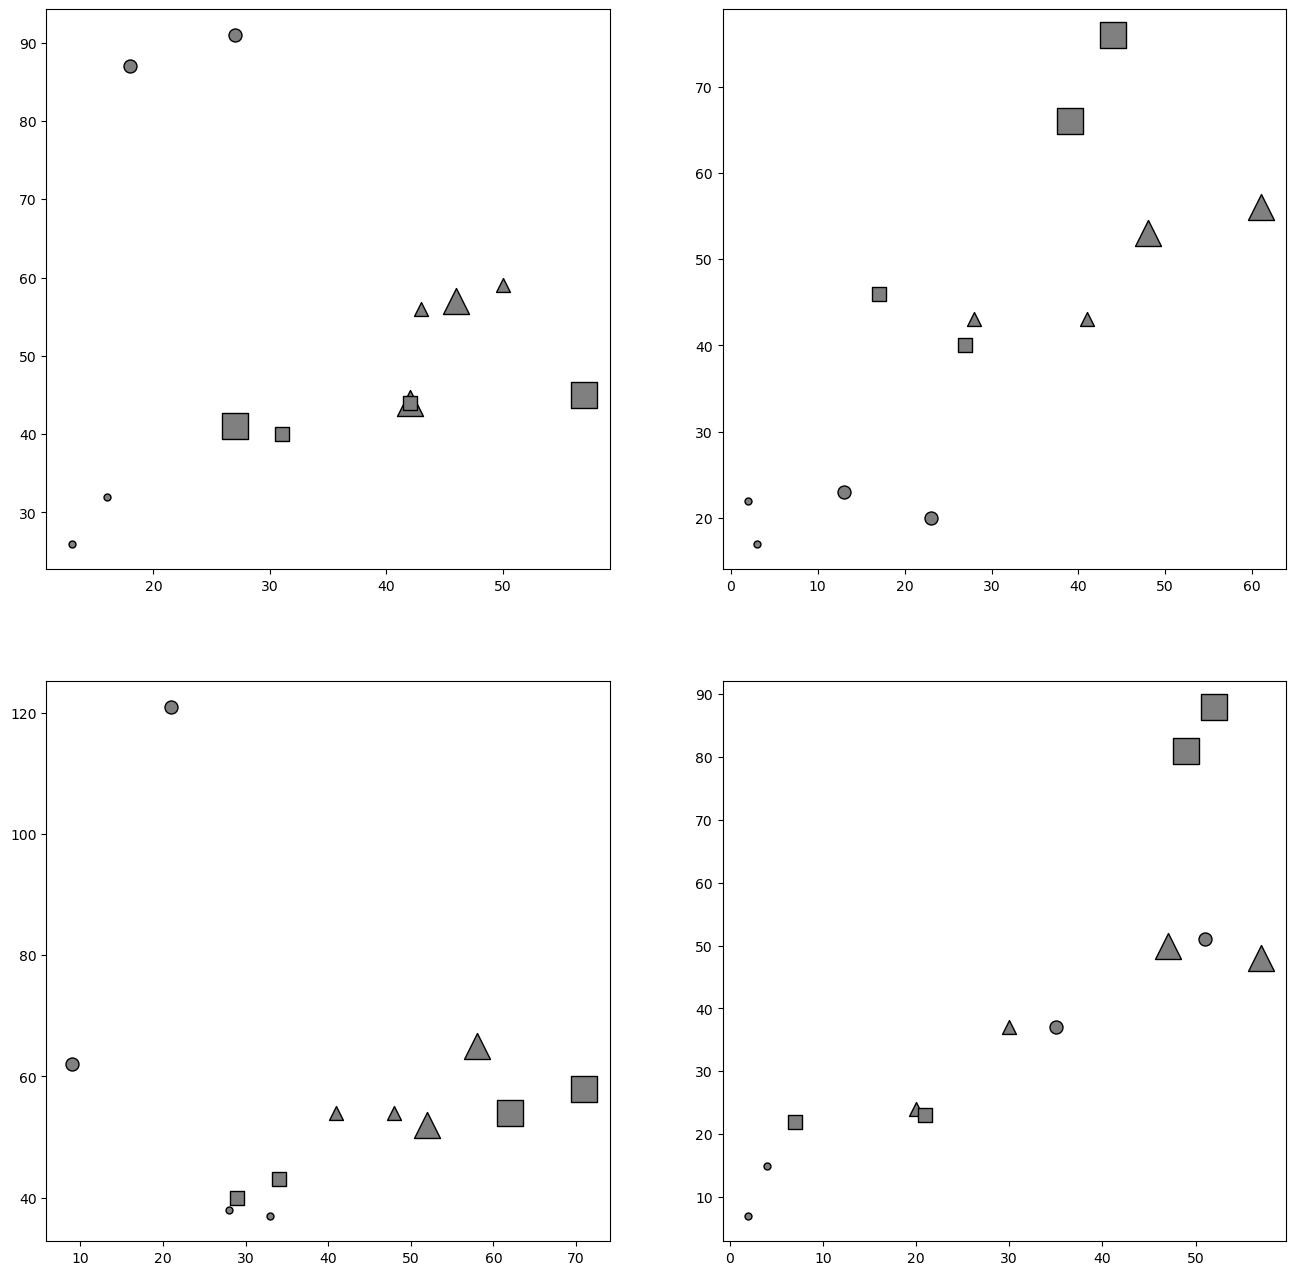

In [38]:


plimk=5
plimg=5
plimr=5
plimo=5
xd=2
yd=2
fig, ax = plt.subplots(xd,yd,figsize=(xd*8 ,yd *8))
#x = ((model_dict_seq2['tf_adage'].kegg_ps > plimk).sum(0) > 0).sum()
#y = ((model_dict_seq2['tf_adage'].kegg_ps > plimk).sum(1) > 0).sum()
#ax[0,0].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[0,0].set(title = 'KEGG', xlabel = 'Total Paths', ylabel = 'Sigs with Paths')

#x = ((model_dict_da_reps['tf_adage'].go_ps > plimg).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].go_ps > plimg).sum(1) > 0).sum()
#ax[0,1].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[0,1].set(title = 'GO', xlabel = 'Total BP', ylabel = 'Sigs with BP')

#x = ((model_dict_da_reps['tf_adage'].regs_ps > plimr).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].regs_ps > plimr).sum(1) > 0).sum()
#ax[1,0].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[1,0].set(title = 'Regulons', xlabel = 'Total Regs', ylabel = 'Sigs with Regs')

#x = ((model_dict_da_reps['tf_adage'].ops_ps > plimo).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].ops_ps > plimo).sum(1) > 0).sum()
#ax[1,1].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[1,1].set(title = 'Operons', xlabel = 'Total Operons', ylabel = 'Sigs with Operons')

xi = 0
yi = 0
c = 'grey'

# edge color is tied or unties
ec = ['black','red','blue','green','purple']
eci=0

# shape is activation function
ms = ['.','s', '^','h']
mi=0

# size is L1 norm
s=50

for seed in range(1):
    for i in inits:
        s=100
    #print(i)
        for l in L1_norm:
            xi=0
            mi=0
        #print(l)
            for a in act_fun:
                m = ms[mi]
                eci=0
            #print(a)
                for t in tied:
                    name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                    print(name)
                    model_temp = model_dict_seq2[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax[0,0].scatter(x, y, c = c, marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_seq2CTRL[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax[0,1].scatter(x, y, c = c, marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_pre[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax[1,0].scatter(x, y, c = c, marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_preCTRL[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax[1,1].scatter(x, y, c = c, marker = m, edgecolor = ec[eci], s=s)
                    eci = eci+1
                mi = mi+1
            s=s+250
        c = 'grey'
                    


ad_glorot_uniform_0_sigmoid_tiedTrue571
ad_glorot_uniform_0_tanh_tiedTrue571
ad_glorot_uniform_0_relu_tiedTrue571
ad_glorot_uniform_1e-05_sigmoid_tiedTrue571
ad_glorot_uniform_1e-05_tanh_tiedTrue571
ad_glorot_uniform_1e-05_relu_tiedTrue571
ad_glorot_normal_0_sigmoid_tiedTrue571
ad_glorot_normal_0_tanh_tiedTrue571
ad_glorot_normal_0_relu_tiedTrue571
ad_glorot_normal_1e-05_sigmoid_tiedTrue571
ad_glorot_normal_1e-05_tanh_tiedTrue571
ad_glorot_normal_1e-05_relu_tiedTrue571


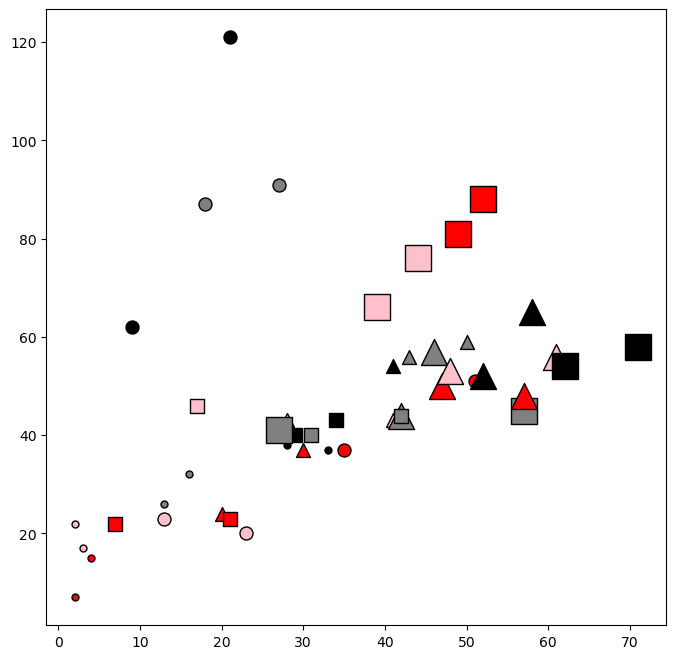

In [39]:

plimk=5
plimg=5
plimr=5
plimo=5
xd=1
yd=1
fig, ax = plt.subplots(xd,yd,figsize=(xd*8 ,yd *8))
#x = ((model_dict_seq2['tf_adage'].kegg_ps > plimk).sum(0) > 0).sum()
#y = ((model_dict_seq2['tf_adage'].kegg_ps > plimk).sum(1) > 0).sum()
#ax[0,0].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[0,0].set(title = 'KEGG', xlabel = 'Total Paths', ylabel = 'Sigs with Paths')

#x = ((model_dict_da_reps['tf_adage'].go_ps > plimg).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].go_ps > plimg).sum(1) > 0).sum()
#ax[0,1].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[0,1].set(title = 'GO', xlabel = 'Total BP', ylabel = 'Sigs with BP')

#x = ((model_dict_da_reps['tf_adage'].regs_ps > plimr).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].regs_ps > plimr).sum(1) > 0).sum()
#ax[1,0].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[1,0].set(title = 'Regulons', xlabel = 'Total Regs', ylabel = 'Sigs with Regs')

#x = ((model_dict_da_reps['tf_adage'].ops_ps > plimo).sum(0) > 0).sum()
#y = ((model_dict_da_reps['tf_adage'].ops_ps > plimo).sum(1) > 0).sum()
#ax[1,1].scatter(x, y, c = 'yellow', marker = '*', edgecolor ='black', s=1000)
#ax[1,1].set(title = 'Operons', xlabel = 'Total Operons', ylabel = 'Sigs with Operons')

xi = 0
yi = 0
c = 'grey'

# edge color is tied or untied
ec = ['black','red','blue','green','purple']
eci=0

# shape is activation function
ms = ['.','s', '^','h']
mi=0

# size is L1 norm
s=50

for seed in range(1):
    for i in inits:
        s=100
    #print(i)
        for l in L1_norm:
            xi=0
            mi=0
        #print(l)
            for a in act_fun:
                m = ms[mi]
                eci=0
            #print(a)
                for t in tied:
                    name = 'ad_' + i + '_' + str(l) + '_' + a + '_tied' + str(t) + str(571)
                    print(name)
                    model_temp = model_dict_seq2[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax.scatter(x, y, c = 'grey', marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_seq2CTRL[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax.scatter(x, y, c = 'pink', marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_pre[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax.scatter(x, y, c = 'black', marker = m, edgecolor = ec[eci], s=s)
                    
                    model_temp = model_dict_preCTRL[name]
                    x = ((model_temp.kegg_ps > plimk).sum(0) > 0).sum()
                    y = ((model_temp.kegg_ps > plimk).sum(1) > 0).sum()
                    ax.scatter(x, y, c = 'red', marker = m, edgecolor = ec[eci], s=s)
                    eci = eci+1
                mi = mi+1
            s=s+250
        c = 'grey'
                    
